# Task 0: Imports and preliminaries

In [ ]:
import numpy as np
import torch
import torch.nn as nn

In [ ]:
RANDOM_SEED = 2026 # for reproducibility
rng = np.random.default_rng(RANDOM_SEED)

# Task 1: LSTM Classifier Trained from Scratch

## 1.0: Loading the data set

In [ ]:
from datasets import load_dataset, get_dataset_split_names

In [ ]:
get_dataset_split_names("ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

['train', 'test']

In [ ]:
dataset = load_dataset('ag_news', split='train')

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

With a size of only 18.6 M, our training data easily fits in RAM.

In [ ]:
test_dataset = load_dataset('ag_news', split='test')

## 1.1 Data Split

We split off a portion of our training data to use as a validation set following a 90-10 split.

In [ ]:
#from sklearn.model_selection import train_test_split
#train_df, valid_df = train_test_split(df, train_size = 0.9, random_state=RANDOM_SEED)

In [ ]:
split = dataset.train_test_split(train_size=0.9)
train_dataset = split['train']
valid_dataset = split['test']

## 1.2 Tokenization and Vocabulary

We implement our word-level tokenizer using the Hugging Face tokenizers libraries.

In [ ]:
from tokenizers import (
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer
)

In [ ]:
wltokenizer = Tokenizer(models.WordLevel(unk_token = "[UNK]"))

As a bonus, we'll also train our model with a WordPiece tokenizer. See the write-up for a high levl description of this algorithm.

In [ ]:
wptokenizer = Tokenizer(models.WordPiece(unk_token = "[UNK]"))

#### 1.2.1: Normalization

We will lowercase and strip accents from words prior to tokenization. According to he Hugging Face documentation, for StripAccents to work correctly it assumes NFD encoding of uni-code characters in order to properly identify accents to strip.

In [ ]:
wltokenizer.normalizer = normalizers.Sequence([
    normalizers.NFD(), normalizers.Lowercase(), normalizers.StripAccents()
])

wptokenizer.normalizer = normalizers.Sequence([
    normalizers.NFD(), normalizers.Lowercase(), normalizers.StripAccents()
])

#### 1.2.2 Pre-tokenization

We specify here that we wil split on whitespace and punctuation. Despite its name, pre_tokenizers.WhiteSpace() handles both of these.

In [ ]:
wltokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

In [ ]:
wptokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

#### 1.2.3 Model (i.e. tokenizer) trainer

Here we add special our special tokens for unknown words and paddin to our vocabulary, and specify that the minimum frequency in the corpus for a word to be included in the vocabulary is 2.

In [ ]:
special_tokens = ["[UNK]", "[PAD]"]
wl_token_trainer = trainers.WordLevelTrainer(min_frequency = 2, special_tokens=special_tokens)
wp_token_trainer = trainers.WordPieceTrainer(special_tokens=special_tokens)

#### 1.2.4 Generator for loading data

The canonical approach to train a hugging face tokenizer is to define a generator that loads batches of training inputs into memory at a time, and to pass this to the model using its ```train_from_iterator()``` method. This allows memory-efficient retrieval of very large data-sets.

Note: we must be careful to only train our tokenizer on the training split.

In [ ]:
def get_corpus_batch(batch_size=1000):
  for i in range(0, len(train_dataset), batch_size):
    yield train_dataset['text'][i : i + batch_size]

#### 1.2.5 Training the tokenizer

In [ ]:
wltokenizer.train_from_iterator(get_corpus_batch(), trainer=wl_token_trainer)

In [ ]:
wptokenizer.train_from_iterator(get_corpus_batch(), trainer=wp_token_trainer)

Let's see what an encoding of our tokenizers looks like on a random training sample.

In [ ]:
sample_idx = int(rng.integers(len(train_dataset)))

In [ ]:
sample_text = train_dataset['text'][sample_idx]
print(sample_text)

Bank bomb blasts kill one A series of bombings ripped through three banks Wednesday in downtown Buenos Aires killing one security guard and injuring a member of the bomb squad.


Our word-level tokenizer produces:

In [ ]:
wl_sample_encoding = wltokenizer.encode(sample_text)
print(wl_sample_encoding.tokens)

['bank', 'bomb', 'blasts', 'kill', 'one', 'a', 'series', 'of', 'bombings', 'ripped', 'through', 'three', 'banks', 'wednesday', 'in', 'downtown', 'buenos', 'aires', 'killing', 'one', 'security', 'guard', 'and', 'injuring', 'a', 'member', 'of', 'the', 'bomb', 'squad', '.']


Our WordPiece tokenizer produces:

In [ ]:
wp_sample_encoding = wptokenizer.encode(sample_text)
print(wp_sample_encoding.tokens)

['bank', 'bomb', 'blasts', 'kill', 'one', 'a', 'series', 'of', 'bombings', 'ripped', 'through', 'three', 'banks', 'wednesday', 'in', 'downtown', 'buenos', 'aires', 'killing', 'one', 'security', 'guard', 'and', 'injuring', 'a', 'member', 'of', 'the', 'bomb', 'squad', '.']


The two tokenizers produce similar looking tokenizations. However, we can see that the vocabulary differs:

In [ ]:
def print_vocab(tokenizer, n):
  vocab = tokenizer.get_vocab()

  # Sort by ID to get deterministic order
  sorted_tokens = sorted(vocab.items(), key=lambda x: x[1])

  # Print first n
  for token, id in sorted_tokens[:n]:
    print(id, token)

In [ ]:
print_vocab(wltokenizer, 20)

0 [UNK]
1 [PAD]
2 the
3 .
4 ,
5 to
6 -
7 a
8 of
9 in
10 ;
11 and
12 s
13 on
14 for
15 #
16 39
17 (
18 )
19 '


In [ ]:
print_vocab(wptokenizer, 20)

0 [UNK]
1 [PAD]
2 !
3 "
4 #
5 $
6 &
7 '
8 (
9 )
10 *
11 ,
12 -
13 .
14 /
15 0
16 1
17 2
18 3
19 4


As we would expect of the WordPiece algorithm, the first entries in its vocabulary are just atomic characters that appear in the corpus. Subwords appear later in the vocabulary after merges take place.

In [ ]:
wpvocab = wptokenizer.get_vocab()

# Filter all subword tokens starting with ##
subwords = {token: id for token, id in wpvocab.items() if token.startswith("##")}

print(list(subwords.items())[:20])

[('##42', 19676), ('##feed', 18202), ('##has', 8064), ('##abad', 4465), ('##umonia', 25820), ('##unga', 24225), ('##uff', 2947), ('##rera', 12921), ('##etched', 28100), ('##oub', 23191), ('##orks', 1856), ('##aters', 13532), ('##icit', 2859), ('##nick', 23907), ('##etect', 29535), ('##iro', 4887), ('##kilis', 26749), ('##set', 2444), ('##mond', 4817), ('##matic', 16468)]


The WordPiece tokenizer we've trained follows the BERT convention: incomplete subwords are prepended by "##".

## 1.3 Padding and LTSM input handling

We define a pytorch DataSet to feed into a PyTorch DataLoader that we will use to pass samples into our LTSM. Our DataSet subclass is where we handle truncating input sequences to the max_seq_length hyperparameter, which we initialize to 128.

In [ ]:
max_seq_length = 128

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class AGNewsDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=max_seq_length):
        self.data = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]

        encoding = self.tokenizer.encode(text)
        ids = encoding.ids[:self.max_len] # truncation to max sequence length

        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

We will handle the problem of input sequences having different lengths by defining a custom collate_fn that we will passs to our DataLoader. The collate_fn parameter of the DataLoader is a callable that tells the DataLoader how to join different samples into a single batch. ```torch.nn.utils.rnn``` contains a convenience function, ```pad_sequence```, that will allow us to pad all of the sequences in a batch to the same length using the the ```[PAD]``` token we defined in our tokenizer.

In [ ]:
from torch.nn.utils.rnn import pad_sequence
WL_PAD_ID = wltokenizer.token_to_id('[PAD]')
WP_PAD_ID = wptokenizer.token_to_id('[PAD]')

In [ ]:
def collate_fn(batch, padding_value):
    sequences, labels = zip(*batch)
    # Unlike a typical batching function, we must also return
    # the lengths of each sequence in the batch for length-aware
    # forward passes that stop updating the hidden state once we reach
    # the padded portion
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=padding_value)
    labels = torch.stack(labels)
    return padded, labels, lengths

def wl_collate_fn(batch):
  return collate_fn(batch, WL_PAD_ID)

def wp_collate_fn(batch):
  return collate_fn(batch, WP_PAD_ID)

When we define the ```forward``` function of our model, we will use length aware LSTM processing to skip the PAD tokens we add to our sequences.

## 1.4 Model Architecture

We implement an LTSM architecture that uses the "last hidden state" pooling strategy to stop updating the hidden state on an input sequence after we reach the padding tokens. PyTorch offers the function ```pack_padded_sequence()``` to handle this for us. Since we are only using the final hidden state, we do not need to perform the inverse operation ```pad_packed_sequence()``` after the LSTM layer.

We use the hyperparameters recommended in the assignment description as the default hyperparameters.

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self,
                 tokenizer,
                 embed_dim=128,
                 hidden_dim=256,
                 num_layers=1,
                 drop_out=0.2):
        vocab_size=tokenizer.get_vocab_size()
        pad_idx=tokenizer.token_to_id('[PAD]')
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=drop_out)
        self.fc = nn.Linear(hidden_dim, 4) # ag_news has 4 class labels

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        # Pack the padded sequence so the LSTM ignores padding tokens
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),         # must be on CPU
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)
        # hidden shape: (num_layers, batch, hidden_dim)
        # Take the last layer's hidden state
        last_hidden = hidden[-1]   # (batch, hidden_dim)

        return self.fc(last_hidden)

## 1.5 Training

We use the training hyperparemeters recommended in the assignment description.

In [ ]:
learning_rate = 0.001
batch_size=64
epochs=6
global_norm=1 # for gradient clipping

# Initialize models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
wl_model = LSTMClassifier(wltokenizer).to(device)
wp_model = LSTMClassifier(wptokenizer).to(device)

# Loss and optimizer
wl_criterion = nn.CrossEntropyLoss()
wp_criterion = nn.CrossEntropyLoss()
wl_optimizer = torch.optim.Adam(wl_model.parameters(), lr=learning_rate)
wp_optimizer = torch.optim.Adam(wp_model.parameters(), lr=learning_rate)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [ ]:
# Verify we're on GPU
print(device)

cuda


### 1.5.1 Data Loaders

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
wl_train_set = AGNewsDataset(train_dataset, wltokenizer)
wl_valid_set  = AGNewsDataset(valid_dataset,  wltokenizer)

wl_train_loader = DataLoader(wl_train_set, batch_size=batch_size, shuffle=True,  collate_fn=wl_collate_fn)
wl_valid_loader = DataLoader(wl_valid_set,  batch_size=batch_size, shuffle=False, collate_fn=wl_collate_fn)

In [ ]:
wp_train_set = AGNewsDataset(train_dataset, wptokenizer)
wp_valid_set  = AGNewsDataset(valid_dataset, wptokenizer)

wp_train_loader = DataLoader(wp_train_set, batch_size=batch_size, shuffle=True,  collate_fn=wp_collate_fn)
wp_valid_loader = DataLoader(wp_valid_set,  batch_size=batch_size, shuffle=False, collate_fn=wp_collate_fn)

### 1.5.2 Training Loop

In [ ]:
def train_loop(model, criterion, optimizer, train_loader, valid_loader):
  history = {
      "train_loss": [],
      "val_loss": [],
      "val_acc": []
  }

  # Training loop ---
  for epoch in range(1, epochs + 1):

      # Train
      model.train()
      running_loss = 0.0

      for padded, labels, lengths in train_loader:
          padded, labels, lengths = padded.to(device), labels.to(device), lengths.to(device)

          optimizer.zero_grad()
          logits = model(padded, lengths)
          loss   = criterion(logits, labels)
          loss.backward()

          # Gradient clipping
          nn.utils.clip_grad_norm_(model.parameters(), max_norm=global_norm)

          optimizer.step()
          # By default, loss.item() will return the average loss of
          # a single sequence in the batch. So we multiply by the number
          # sequences in a batch to recover the average loss over all
          # training samples.
          running_loss += loss.item() * len(labels)

      train_loss = running_loss / len(train_loader.dataset)

      # Validate
      model.eval()
      val_loss_sum = 0.0
      correct = 0

      with torch.no_grad():
          for padded, labels, lengths in valid_loader:
              padded, labels, lengths = padded.to(device), labels.to(device), lengths.to(device)

              logits = model(padded, lengths)
              loss   = criterion(logits, labels)

              val_loss_sum += loss.item() * len(labels)
              correct += (logits.argmax(dim=1) == labels).sum().item()

      val_loss = val_loss_sum / len(valid_loader.dataset)
      val_acc  = correct / len(valid_loader.dataset)

      # Record and print
      history["train_loss"].append(train_loss)
      history["val_loss"].append(val_loss)
      history["val_acc"].append(val_acc)

      print(
          f"Epoch {epoch}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}"
      )

  return history

In [ ]:
import time

In [ ]:
start = time.time()
wl_history = train_loop(wl_model, wl_criterion, wl_optimizer, wl_train_loader, wl_valid_loader)
end = time.time()

wl_train_time = end - start
print(f"Training Time: {wl_train_time:.4f} seconds")

Epoch 1/6 | Train Loss: 0.0101 | Val Loss: 0.5318 | Val Acc: 0.9139
Epoch 2/6 | Train Loss: 0.0109 | Val Loss: 0.5304 | Val Acc: 0.9121
Epoch 3/6 | Train Loss: 0.0099 | Val Loss: 0.5588 | Val Acc: 0.9125
Epoch 4/6 | Train Loss: 0.0081 | Val Loss: 0.5486 | Val Acc: 0.9132
Epoch 5/6 | Train Loss: 0.0068 | Val Loss: 0.5781 | Val Acc: 0.9124
Epoch 6/6 | Train Loss: 0.0072 | Val Loss: 0.5905 | Val Acc: 0.9138
Training Time: 409.6208 seconds


In [ ]:
start = time.time()
wp_history = train_loop(wp_model, wp_criterion, wp_optimizer, wp_train_loader, wp_valid_loader)
end = time.time()

wp_train_time = end - start
print(f"Training Time: {wp_train_time:.4f} seconds")

Epoch 1/6 | Train Loss: 0.0383 | Val Loss: 0.3924 | Val Acc: 0.9129
Epoch 2/6 | Train Loss: 0.0283 | Val Loss: 0.4413 | Val Acc: 0.9106
Epoch 3/6 | Train Loss: 0.0229 | Val Loss: 0.4467 | Val Acc: 0.9131
Epoch 4/6 | Train Loss: 0.0168 | Val Loss: 0.5093 | Val Acc: 0.9105
Epoch 5/6 | Train Loss: 0.0167 | Val Loss: 0.5197 | Val Acc: 0.9102
Epoch 6/6 | Train Loss: 0.0147 | Val Loss: 0.5155 | Val Acc: 0.9124
Training Time: 439.2808 seconds


### 1.5.3 Learning Curves

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   marker="o", label="Val Loss")
ax1.set_title("Loss over Training")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Validation accuracy
ax2.plot(epochs_range, history["val_acc"], marker="o", color="green", label="Val Accuracy")
ax2.set_title("Validation Accuracy over Training")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

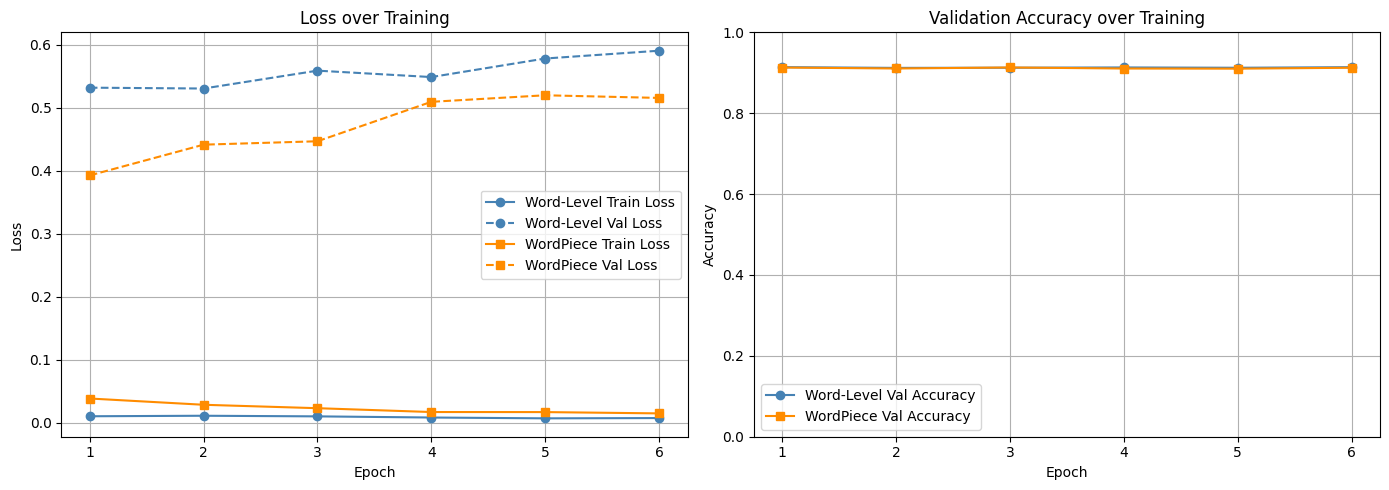

In [ ]:
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
ax1.plot(epochs_range, wl_history["train_loss"], marker="o", color="steelblue",   label="Word-Level Train Loss")
ax1.plot(epochs_range, wl_history["val_loss"],   marker="o", color="steelblue",   label="Word-Level Val Loss",   linestyle="--")
ax1.plot(epochs_range, wp_history["train_loss"], marker="s", color="darkorange",  label="WordPiece Train Loss")
ax1.plot(epochs_range, wp_history["val_loss"],   marker="s", color="darkorange",  label="WordPiece Val Loss",    linestyle="--")
ax1.set_title("Loss over Training")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# --- Validation accuracy ---
ax2.plot(epochs_range, wl_history["val_acc"], marker="o", color="steelblue",  label="Word-Level Val Accuracy")
ax2.plot(epochs_range, wp_history["val_acc"], marker="s", color="darkorange", label="WordPiece Val Accuracy")
ax2.set_title("Validation Accuracy over Training")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### 1.5.4 Model size (number of parameters)

Note that the architectures of both the model trained on the WordLevel tokenized data and the model trained on the WordPiece tokenized data is the same: it is only the tokenizer that differs.

The number of (trainable) parameters in the model is:

In [ ]:
LTSM_param_count = sum(p.numel() for p in wl_model.parameters() if p.requires_grad)
print(f"Parameter count: {LTSM_param_count:,}")

Parameter count: 4,236,292


## 1.6 Testing the Model

Let's evaluate both of our models on the test set to report test accuracy.

In [ ]:
def evaluate_on_test(model, criterion, tokenizer, test_dataset, collate_fn):
    test_set = AGNewsDataset(test_dataset, tokenizer)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model.eval()
    test_loss_sum = 0.0
    correct = 0

    with torch.no_grad():
        for padded, labels, lengths in test_loader:
            padded, labels, lengths = padded.to(device), labels.to(device), lengths.to(device)

            logits = model(padded, lengths)
            loss = criterion(logits, labels)

            test_loss_sum += loss.item() * len(labels)
            correct += (logits.argmax(dim=1) == labels).sum().item()

    test_loss = test_loss_sum / len(test_loader.dataset)
    test_acc = correct / len(test_loader.dataset)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

In [ ]:
print("Word-Level LSTM:")
evaluate_on_test(wl_model, wl_criterion, wltokenizer, test_dataset, wl_collate_fn)

Word-Level LSTM:
Test Loss: 0.6199 | Test Accuracy: 0.9183


In [ ]:
print("WordPiece LSTM:")
evaluate_on_test(wp_model, wp_criterion, wptokenizer, test_dataset, wp_collate_fn)

WordPiece LSTM:
Test Loss: 0.4952 | Test Accuracy: 0.9118


Let's also invesitage a couple misclassified examples of each model

In [ ]:
num_misclassified_examples = 5

In [ ]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

def show_misclassified(model, tokenizer, collate_fn, test_dataset, n=num_misclassified_examples):
    test_set = AGNewsDataset(test_dataset, tokenizer)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model.eval()
    misclassified = []

    with torch.no_grad():
        # Track the global sample index across batches
        sample_idx = 0
        for padded, labels, lengths in test_loader:
            padded, labels, lengths = padded.to(device), labels.to(device), lengths.to(device)

            logits = model(padded, lengths)
            preds = logits.argmax(dim=1)

            wrong_mask = (preds != labels)
            wrong_indices = wrong_mask.nonzero(as_tuple=True)[0]

            for i in wrong_indices:
                global_idx = sample_idx + i.item()
                misclassified.append({
                    "text":      test_dataset[global_idx]["text"],
                    "true":      label_names[labels[i].item()],
                    "predicted": label_names[preds[i].item()]
                })
                if len(misclassified) >= n:
                    break

            sample_idx += len(labels)
            if len(misclassified) >= n:
                break

    for j, ex in enumerate(misclassified, 1):
        print(f"--- Example {j} ---")
        print(f"Text:      {ex['text'][:max_seq_length]}")
        print(f"True:      {ex['true']}")
        print(f"Predicted: {ex['predicted']}")
        print()

In [ ]:
print("=== Word-Level LSTM Misclassifications ===")
show_misclassified(wl_model, wltokenizer, wl_collate_fn, test_dataset)

=== Word-Level LSTM Misclassifications ===
--- Example 1 ---
Text:      Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorf
True:      Sci/Tech
Predicted: World

--- Example 2 ---
Text:      Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards 
True:      Sci/Tech
Predicted: Business

--- Example 3 ---
Text:      IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
True:      Sci/Tech
Predicted: Business

--- Example 4 ---
Text:      Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process
True:      Sci/Tech
Predicted: Business

--- Example 5 ---
Text:      1994 Law Designed to Preserve Guard Jobs (AP) AP - A 1994 law strengthened job protections for National Guard and Reserve troops
True:    

In [ ]:
print("=== WordPiece LSTM Misclassifications ===")
show_misclassified(wp_model, wptokenizer, wp_collate_fn, test_dataset)

=== WordPiece LSTM Misclassifications ===
--- Example 1 ---
Text:      Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorf
True:      Sci/Tech
Predicted: Sports

--- Example 2 ---
Text:      Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards 
True:      Sci/Tech
Predicted: Business

--- Example 3 ---
Text:      IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
True:      Sci/Tech
Predicted: Business

--- Example 4 ---
Text:      Tougher rules won't soften Law's game FOXBOROUGH -- Looking at his ridiculously developed upper body, with huge biceps and hardl
True:      Sports
Predicted: World

--- Example 5 ---
Text:      Retailers Vie for Back-To-School Buyers (Reuters) Reuters - Apparel retailers are hoping their\back-to-school fashions will make
True:      Bus

# Task 2: Fine-tune a Pretrained Transformer

We'll see how our custom LSTM classifier compares to a pretrained transformer model: ```distilbert```.


In [ ]:
model_checkpoint = 'distilbert-base-uncased'

## 2.1 Tokenization, Padding, Truncation and Attention Masks

We'll load the tokenizer for ```distilbert``` and other HuggingFace dependencies.

In [ ]:
from transformers import AutoTokenizer

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

```distilbert``` uses the same tokenizer as BERT: the WordPiece tokenization algorithm. Unlike our LSTM's word level tokenization, the WordPiece algorithm breaks up the tokens in its vocabulary into subwords. For a concrete example, lets see how the BERT tokenizer encoding compares to the output of our word level tokenizer on the random sample from earlier:

In [ ]:
print(sample_text)

World #39;s strongest man strikes again Iranians are swelling with pride after weightlifter Hossein Rezazadeh confirmed his status as the world #39;s strongest man at the Athens Olympics.


Recall that our WordLevel tokenizer's encoding looked like:

In [ ]:
print(wl_sample_encoding.tokens)

['bank', 'bomb', 'blasts', 'kill', 'one', 'a', 'series', 'of', 'bombings', 'ripped', 'through', 'three', 'banks', 'wednesday', 'in', 'downtown', 'buenos', 'aires', 'killing', 'one', 'security', 'guard', 'and', 'injuring', 'a', 'member', 'of', 'the', 'bomb', 'squad', '.']


On this same sample text, the BERT WordPiece tokenizer produces:

In [ ]:
bert_sample_encoding = bert_tokenizer(sample_text)
print(bert_tokenizer.convert_ids_to_tokens(bert_sample_encoding["input_ids"]))

['[CLS]', 'world', '#', '39', ';', 's', 'strongest', 'man', 'strikes', 'again', 'iranian', '##s', 'are', 'swelling', 'with', 'pride', 'after', 'weight', '##lift', '##er', 'ho', '##sse', '##in', 'reza', '##za', '##deh', 'confirmed', 'his', 'status', 'as', 'the', 'world', '#', '39', ';', 's', 'strongest', 'man', 'at', 'the', 'athens', 'olympics', '.', '[SEP]']


Let's look at the other attributes stored in the batch encoding object returned by the tokenizer:

In [ ]:
print(bert_sample_encoding.keys())

KeysView({'input_ids': [101, 2088, 1001, 4464, 1025, 1055, 10473, 2158, 9326, 2153, 7726, 2015, 2024, 18348, 2007, 6620, 2044, 3635, 18412, 2121, 7570, 11393, 2378, 26323, 4143, 25383, 4484, 2010, 3570, 2004, 1996, 2088, 1001, 4464, 1025, 1055, 10473, 2158, 2012, 1996, 7571, 3783, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]})


In addition to the IDs we saw for the sample input earlier, we see there are two other keys: 'token_type_ids' and 'attention_mask'. 'token_type_ids' is not important for our classification task: it is used by the BERT model to distinguish between different inputs for other tasks such as paraphrase identification, where the model receives two different input sequences and is tasked with identifying whether or not they are paraphrases of eachother. For this task, the token_type_ids would be 0 for sequences belonging to one input, and 1 for the other.

What *is* relevant for our classification task is the attention mask. This is how the BERT model handles the problem of different sequence lengths padding tokens. Whereas before in our LSTM we did this through our length-aware pooling strategy that stopped updating the hidden state on padding tokens, in tranformer like BERT, PAD tokens are zeroed in the attention mask. When a token an value of zero in the mask, the attention that it receives in the transformer model is zeroed.  You'll note that for this input, there are no zeroes in the attention mask. This is because we haven't actually applied the padding yet! Much as we did with our LSTM, we will pad dynamically when we retrieve our batches. We'll pad to the length of the longest sequence in the batch (after truncation). Just as before, we'll specify this in a **collator function.** Hugging face provides a predefined collator function that does precisely what we want called ```DataCollatorWithPadding```.

In [ ]:
from transformers import DataCollatorWithPadding
collate_function = DataCollatorWithPadding(bert_tokenizer)

While we apply our padding dynamically per batch, we handle the remaining preprocessing (e.g. truncation) and converting to IDs before hand on our dataset in accordance with the hugging face documentation best practice. We do this by passing a preprocessing function to the ```map``` function of the data sets we wish to preprocess.

In [ ]:
def preprocess_function(input_batch):
  return bert_tokenizer(input_batch['text'], truncation=True, max_length=max_seq_length)

tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True)
tokenized_valid_dataset = valid_dataset.map(preprocess_function, batched=True)
tokenized_test_dataset  = test_dataset.map(preprocess_function, batched=True)


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## 2.2 Load Model

In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=4)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We'll also train a copy of the model with the transformer weights frozen to compare with our full model. For the frozen model, only the weights in the classification head will update, and we'll be using the weights that ship out-of-the-box for distilbert. Compared to the full model, we expect predictive performance to be lower as a result, but training time to be faster.

In [ ]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=4)

for param in frozen_model.distilbert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Let's see how many trainable parameters each of these models has.

In [ ]:
model_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter count (full): {model_param_count:,}")

Parameter count (full): 66,956,548


In [ ]:
frozen_model_param_count = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"Parameter count (frozen): {frozen_model_param_count:,}")

Parameter count (frozen): 593,668


The bulk of our trainable parameters are in the transformer layers, with the classification head only contributing roughly 600,000 of 67 million parameters in the full model.

## 2.3 Train Model

We'll track loss for both train and validation sets in addition to training accuracy. In Hugging Face, we specify this via the compute_metric() function that we pass to our Trainer object. We will build our compute_metrics function with the metrics predefined in the hugging face Evaluate library.

In [ ]:
!pip install evaluate
import evaluate

In [ ]:
accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

We use the hyperparameters recommended by the assignment. We also use the recommendations for mixed precision and disabling checkpoint saving to speed up training.

In [ ]:
from transformers import Trainer, TrainingArguments

In [ ]:
training_args = TrainingArguments(
    'trainer_output',
    eval_strategy='epoch',
    logging_strategy='epoch',
    report_to='none', # We aren't using experiment tracking tools
    fp16=True,
    save_strategy='no',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.05,
    optim="adamw_torch"
)

In [ ]:
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_valid_dataset,
    data_collator=collate_function,
    processing_class=bert_tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
frozen_trainer = Trainer(
    frozen_model,
    training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_valid_dataset,
    data_collator=collate_function,
    processing_class=bert_tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.236791,0.173687,0.940083
2,0.143868,0.182741,0.948250
3,0.097310,0.207504,0.949500


TrainOutput(global_step=20250, training_loss=0.15932307339891974, metrics={'train_runtime': 1595.8191, 'train_samples_per_second': 203.031, 'train_steps_per_second': 12.689, 'total_flos': 7697686006308480.0, 'train_loss': 0.15932307339891974, 'epoch': 3.0})

In [ ]:
frozen_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.287477,0.278548,0.899333
2,0.281807,0.274320,0.902083
3,0.278697,0.272618,0.903417


Epoch,Training Loss,Validation Loss


TrainOutput(global_step=20250, training_loss=0.28266051793981484, metrics={'train_runtime': 432.4459, 'train_samples_per_second': 749.227, 'train_steps_per_second': 46.827, 'total_flos': 7697686006308480.0, 'train_loss': 0.28266051793981484, 'epoch': 3.0})

### 2.3.1 Learning curves

In [ ]:
log_history = trainer.state.log_history

train_logs = [entry for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
eval_logs  = [entry for entry in log_history if 'eval_loss' in entry]

train_loss = [entry['loss'] for entry in train_logs]
eval_loss  = [entry['eval_loss'] for entry in eval_logs]
eval_acc   = [entry['eval_accuracy'] for entry in eval_logs]
epochs     = [entry['epoch'] for entry in eval_logs]

In [ ]:
log_history_frozen = frozen_trainer.state.log_history

train_logs_frozen = [entry for entry in log_history_frozen if 'loss' in entry and 'eval_loss' not in entry]
eval_logs_frozen  = [entry for entry in log_history_frozen if 'eval_loss' in entry]

train_loss_frozen = [entry['loss'] for entry in train_logs_frozen]
eval_loss_frozen  = [entry['eval_loss'] for entry in eval_logs_frozen]
eval_acc_frozen   = [entry['eval_accuracy'] for entry in eval_logs_frozen]

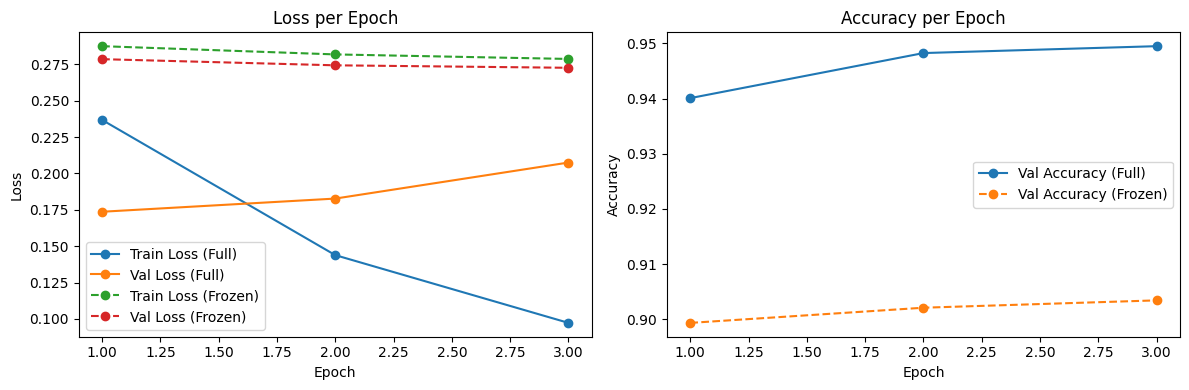

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, marker='o', label='Train Loss (Full)')
ax1.plot(epochs, eval_loss,  marker='o', label='Val Loss (Full)')
ax1.plot(epochs, train_loss_frozen, marker='o', linestyle='--', label='Train Loss (Frozen)')
ax1.plot(epochs, eval_loss_frozen,  marker='o', linestyle='--', label='Val Loss (Frozen)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss per Epoch')
ax1.legend()

ax2.plot(epochs, eval_acc,        marker='o', label='Val Accuracy (Full)')
ax2.plot(epochs, eval_acc_frozen, marker='o', linestyle='--', label='Val Accuracy (Frozen)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy per Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 2.4 Test Model

We evaluate both full and frozen models on the test set to report test accracy

In [ ]:
# Get predictions on test set
test_output = trainer.predict(tokenized_test_dataset)
frozen_test_output = frozen_trainer.predict(tokenized_test_dataset)

# Test accuracy
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids
test_accuracy = (test_preds == test_labels).mean()
print(f"Full Model Test Accuracy full model): {test_accuracy:.4f}")

frozen_test_preds = np.argmax(frozen_test_output.predictions, axis=-1)
frozen_test_labels = frozen_test_output.label_ids
frozen_test_accuracy = (frozen_test_preds == frozen_test_labels).mean()
print(f"Frozen Model Test Accuracy (frozen model): {frozen_test_accuracy:.4f}")

# AG News label mapping
label_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

Full Model Test Accuracy full model): 0.9470
Frozen Model Test Accuracy (frozen model): 0.9020


We also display a few misclassified examples for our full model.

In [ ]:
num_misclassified_examples = 5

In [ ]:
misclassified_indices = np.where(test_preds != test_labels)[0]

print(f"\nShowing {num_misclassified_examples} misclassified examples:\n")

for i in misclassified_indices[:num_misclassified_examples]:
    print(f"Input text:      {test_dataset[int(i)]['text']}")
    print(f"True label:      {label_names[test_labels[i]]}")
    print(f"Predicted label: {label_names[test_preds[i]]}")
    print("-" * 80)


Showing 5 misclassified examples:

Input text:      IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
True label:      Sci/Tech
Predicted label: Business
--------------------------------------------------------------------------------
Input text:      Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.
True label:      Sci/Tech
Predicted label: Business
--------------------------------------------------------------------------------
Input text:      Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.